In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import xml.etree.ElementTree as ET
from collections import Counter
from google.colab import drive
drive.mount('/content/drive')
import os

df = pd.read_csv("/content/drive/MyDrive/train.csv")

print(df.shape)
print(df.head())


Mounted at /content/drive
(50000, 3)
                                           id  \
0            fd61e324e0cec5c11f337d0bfe2858c8   
1            999b3d4d5a860725bf9528910b5612f3   
2            1aaa84517819c25f783ae1c0cb337fc5   
3            919a7da8bd44dc7781dbe87383a268cc   
4  thesantatitan_deepseek-svg-dataset_0000581   

                                              prompt  \
0  The image features two orange squares with a m...   
1  A simple smiley face with a wide open mouth an...   
2  The image features a black-outlined icon of a ...   
3  The image displays a black icon with a photo-l...   
4  Generate svg code for an image that looks like...   

                                                 svg  
0  <svg xmlns="http://www.w3.org/2000/svg" viewBo...  
1  <svg xmlns="http://www.w3.org/2000/svg" viewBo...  
2  <svg xmlns="http://www.w3.org/2000/svg" viewBo...  
3  <svg xmlns="http://www.w3.org/2000/svg" viewBo...  
4  <svg width="24" height="24" viewBox="0 0 24 24...  


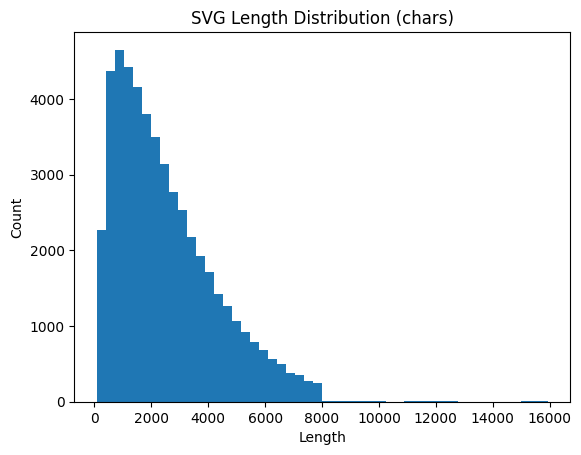

count    50000.000000
mean      2524.277000
std       1773.833419
min         91.000000
25%       1125.000000
50%       2110.000000
75%       3530.000000
max      15937.000000
Name: svg_len_chars, dtype: float64


In [2]:
df["svg_len_chars"] = df["svg"].str.len()

plt.hist(df["svg_len_chars"], bins=50)
plt.title("SVG Length Distribution (chars)")
plt.xlabel("Length")
plt.ylabel("Count")
plt.show()

print(df["svg_len_chars"].describe())


In [3]:
TAG_REGEX = re.compile(r"<(\w+)")

def extract_tags(svg):
  return TAG_REGEX.findall(svg)

all_tags = df["svg"].apply(extract_tags)
tag_counts = Counter([tag for tags in all_tags for tag in tags])

print("Top tags:")
print(tag_counts.most_common(20))


Top tags:
[('path', 121006), ('svg', 50000), ('circle', 13549), ('g', 6101), ('rect', 4323), ('stop', 2821), ('ellipse', 773), ('radialGradient', 682), ('linearGradient', 589), ('line', 572), ('clipPath', 391), ('defs', 343), ('text', 305), ('polygon', 120), ('title', 118), ('use', 75), ('tspan', 54), ('style', 48), ('desc', 33), ('mask', 26)]


In [5]:
duplicates = df["svg"].duplicated().sum()
print("Duplicate SVGs:", duplicates)


Duplicate SVGs: 7


In [6]:
def is_simple(svg):
  return len(svg) < 200

print("Simple SVG %:", df["svg"].apply(is_simple).mean())

Simple SVG %: 0.00358


In [7]:
long_svgs = df[df["svg_len_chars"] > df["svg_len_chars"].quantile(0.99)]
print("Top 1% length:", long_svgs.shape)

Top 1% length: (500, 5)


In [8]:
df = df.drop_duplicates(subset=["svg"], keep="first")
print("Remaining rows:", len(df))
print("Remaining duplicate SVGs:", df["svg"].duplicated().sum())

Remaining rows: 49993
Remaining duplicate SVGs: 0


In [9]:
long_threshold = df["svg_len_chars"].quantile(0.99)
long_df = df[df["svg_len_chars"] >= long_threshold].copy()

print("Long threshold:", long_threshold)
print("Count in top 1%:", len(long_df))

long_df[["id", "prompt", "svg_len_chars"]].sort_values("svg_len_chars", ascending=False).head(20)

Long threshold: 7514.080000000002
Count in top 1%: 500


,id,prompt,svg_len_chars
17055,dddda84f-905c-47bd-8b64-93d4d9861b98,A pair of pruning shears is shown in a black o...,15937
13824,6c24c263-0d3e-491b-808a-4e467bea91c9,A cartoon character with brown hair is shruggi...,15881
31887,f4c6798b-6c39-49c3-8a21-3395f6d0fe19,"A line drawing of a bird, likely a bird of pre...",15833
17357,cfd54977-bcce-40c8-9e67-6f5099cc12f1,A golden ring with a large blue gemstone accen...,15583
31361,672daa8b-19ac-4d16-bfa5-d5afb5de46cc,Figure 1 - Key and Seal,15499
18489,a78a8c3c-641e-44e4-92d8-7b85672a6297,A stylized cartoon explosion with red and yell...,15468
23113,76d8d002-54eb-4414-92cf-5e11dd5a8f2d,The image shows three hands next to each other...,15260
33160,887d457e-836a-42f9-8bee-8cbea9e6c27a,A purple diamond-shaped icon with three square...,15163
23484,e2900ad0-c527-4cc4-b711-8c63a330bb6a,A black and white icon of a folder with a worl...,15038
31427,250cce36-3c33-4d38-b9a0-ffa84a6b1620,"A bedroom with a bed, desk with a computer, an...",14541


In [10]:
long_threshold = df["svg_len_chars"].quantile(0.99)
long_df = df[df["svg_len_chars"] >= long_threshold].copy()

print("Long threshold:", long_threshold)
print("Count in top 1%:", len(long_df))

long_df[["id", "prompt", "svg_len_chars"]].sort_values("svg_len_chars", ascending=False).head(20)

Long threshold: 7514.080000000002
Count in top 1%: 500


,id,prompt,svg_len_chars
17055,dddda84f-905c-47bd-8b64-93d4d9861b98,A pair of pruning shears is shown in a black o...,15937
13824,6c24c263-0d3e-491b-808a-4e467bea91c9,A cartoon character with brown hair is shruggi...,15881
31887,f4c6798b-6c39-49c3-8a21-3395f6d0fe19,"A line drawing of a bird, likely a bird of pre...",15833
17357,cfd54977-bcce-40c8-9e67-6f5099cc12f1,A golden ring with a large blue gemstone accen...,15583
31361,672daa8b-19ac-4d16-bfa5-d5afb5de46cc,Figure 1 - Key and Seal,15499
18489,a78a8c3c-641e-44e4-92d8-7b85672a6297,A stylized cartoon explosion with red and yell...,15468
23113,76d8d002-54eb-4414-92cf-5e11dd5a8f2d,The image shows three hands next to each other...,15260
33160,887d457e-836a-42f9-8bee-8cbea9e6c27a,A purple diamond-shaped icon with three square...,15163
23484,e2900ad0-c527-4cc4-b711-8c63a330bb6a,A black and white icon of a folder with a worl...,15038
31427,250cce36-3c33-4d38-b9a0-ffa84a6b1620,"A bedroom with a bed, desk with a computer, an...",14541


In [11]:
def normalize_whitespace(svg):
  svg = re.sub(r">\s+<", "><", svg)
  svg = re.sub(r"\s{2,}", " ", svg)
  return svg.strip()

df["svg"] = df["svg"].apply(normalize_whitespace)

In [12]:
df["svg_len_chars"] = df["svg"].str.len()
print(df["svg_len_chars"].describe())

count    49993.000000
mean      2518.334567
std       1774.689026
min         90.000000
25%       1115.000000
50%       2107.000000
75%       3527.000000
max      15937.000000
Name: svg_len_chars, dtype: float64


In [13]:
def round_svg_floats(svg, decimals=2):
  pattern = r"(?<![A-Za-z])[-+]?\d*\.\d+"
  def repl(m):
    num = float(m.group())
    rounded = round(num, decimals)
    if rounded.is_integer():
      return str(int(rounded))
    return str(rounded)
  return re.sub(pattern, repl, svg)

df["svg"] = df["svg"].apply(lambda x: round_svg_floats(x, decimals=2))

In [14]:
previous_max_len = 15937.0
df["svg_len_chars"] = df["svg"].str.len()
current_max_len = df["svg_len_chars"].max()

print(f"Maximum SVG length before round_svg_floats: {previous_max_len} characters.")
print(f"Maximum SVG length after round_svg_floats: {current_max_len} characters.")
print(f"The maximum SVG length increased from {previous_max_len} to {current_max_len} after applying round_svg_floats.")

Maximum SVG length before round_svg_floats: 15937.0 characters.
Maximum SVG length after round_svg_floats: 19179 characters.
The maximum SVG length increased from 15937.0 to 19179 after applying round_svg_floats.


In [15]:
def is_valid_svg(svg_text):
  if not svg_text:
    return False
  try:
    root = ET.fromstring(svg_text)
    return root.tag.endswith("svg")
  except ET.ParseError:
    return False

In [16]:
valid_before = df["svg"].apply(is_valid_svg)
print("Valid before:", valid_before.mean())



Valid before: 1.0


In [17]:
valid_before = df["svg"].apply(is_valid_svg)
print("Valid before:", valid_before.mean())

Valid before: 1.0


In [18]:
df = df[df["svg_len_chars"] <= 6000].copy()

In [19]:
df["svg_len_chars"] = df["svg"].str.len()
print(df["svg_len_chars"].describe())

count    49772.000000
mean      1234.329342
std        731.203677
min         90.000000
25%        683.000000
50%       1066.000000
75%       1626.000000
max       5997.000000
Name: svg_len_chars, dtype: float64


In [20]:
df.columns

Index(['id', 'prompt', 'svg', 'svg_len_chars', 'num_elements'], dtype='object')

In [21]:
output_path = "/content/drive/MyDrive/train_clean.csv"
df.to_csv(output_path, index=False)
print(os.path.exists(output_path))

True
